# EXPLORATORY DATA ANALYSIS AND PREDICTION OF TITANIC SURVIVAL

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

C:\Users\prade\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [5]:
df=pd.read_csv("titanic_train.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [24]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
df.shape

(891, 12)

# CLEANING

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

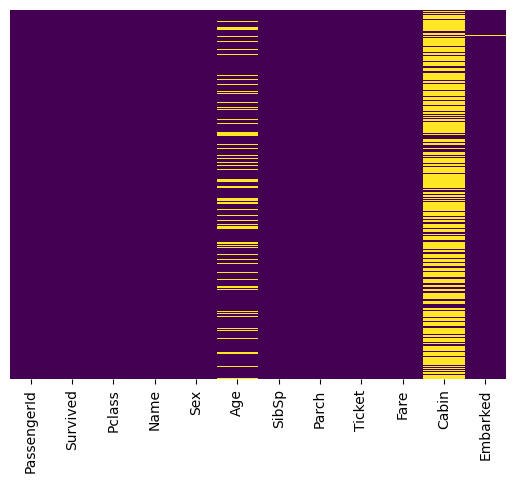

In [7]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [28]:
#i dont want to drop all the column which consist null values so here instead of removing all columns i will remove unnecesary column which does not affect the analysis

In [22]:
df.drop(['PassengerId','Ticket','Fare','Cabin','Name'],axis=1,inplace=True)

In [30]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Embarked      2
dtype: int64

In [23]:
df['Embarked']=df['Embarked'].fillna(value='S')

In [32]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Embarked      0
dtype: int64

In [33]:
#df['Embarked'].value_counts()

C:\Users\prade\AppData\Local\Temp\ipykernel_5516\3589502886.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Pclass',y='Age',data=df,palette='winter')


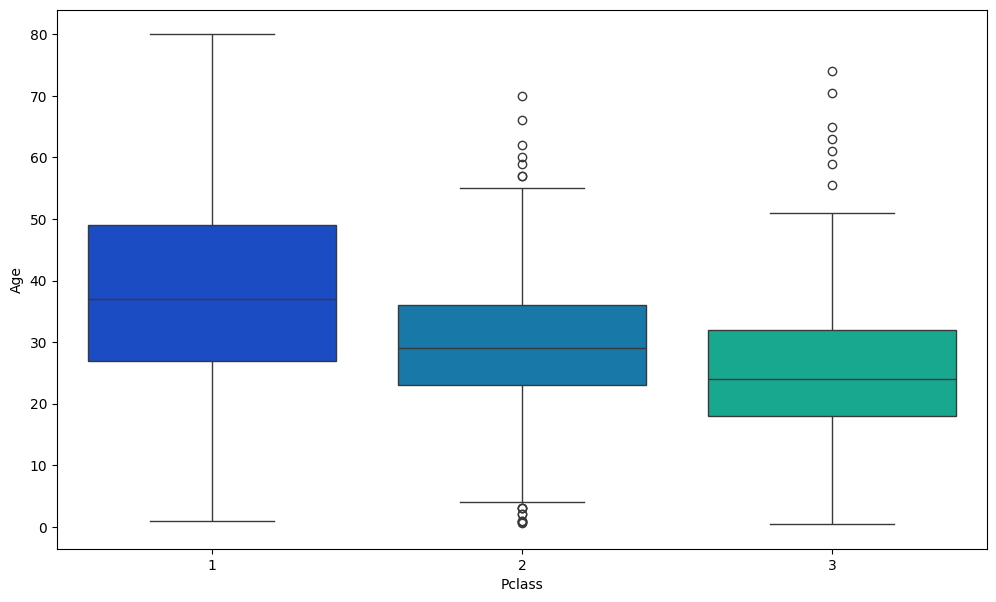

In [41]:
plt.figure(figsize=(12, 7))
sns.boxplot(x='Pclass',y='Age',data=df,palette='winter')
plt.show()

#####  We can see the wealthier passengers in the higher classes tend to be older, which makes sense. We'll use these average age values to impute based on Pclass for Age.

In [24]:
def impute_age(cols):
    Age = cols['Age']
    Pclass = cols['Pclass']

    if pd.isnull(Age):
        if Pclass == 1:
            return 37
        elif Pclass == 2:
            return 29
        else:
            return 24
    else:
        return Age

In [25]:
df['Age'] = df[['Age','Pclass']].apply(impute_age,axis=1)

In [26]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Embarked    0
dtype: int64

In [34]:
df.duplicated()

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [49]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [50]:
df.tail()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
886,0,2,male,27.0,0,0,S
887,1,1,female,19.0,0,0,S
888,0,3,female,24.0,1,2,S
889,1,1,male,26.0,0,0,C
890,0,3,male,32.0,0,0,Q


# EDA

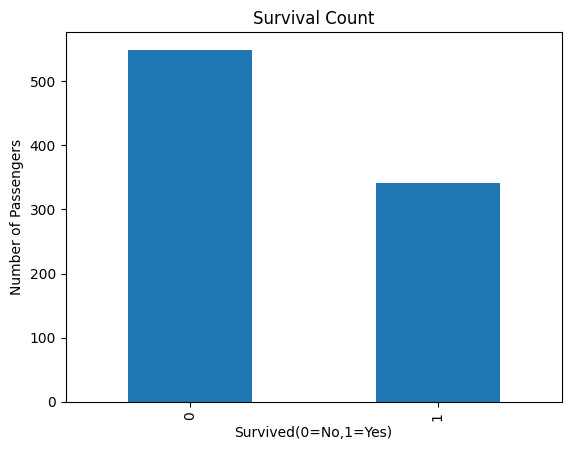

In [41]:
df['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Count")
plt.xlabel("Survived(0=No,1=Yes)")
plt.ylabel("Number of Passengers")
plt.show()

C:\Users\prade\AppData\Local\Temp\ipykernel_14924\2271557996.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived',data=df,palette='RdBu_r')


<Axes: xlabel='Survived', ylabel='count'>

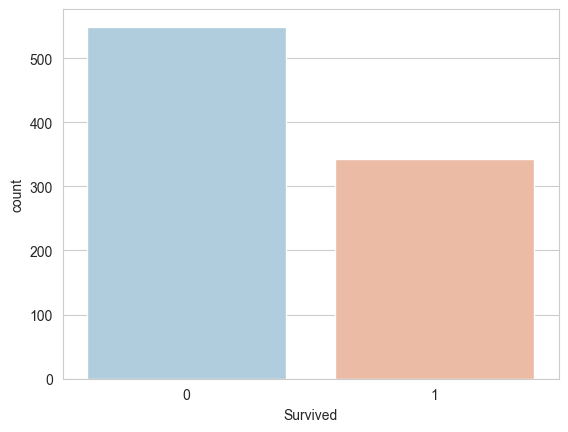

In [11]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',data=df,palette='RdBu_r')

In [56]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

#### Findings
most of the passengers didnt survived.the number of death is significantlly higher than the number of survivors


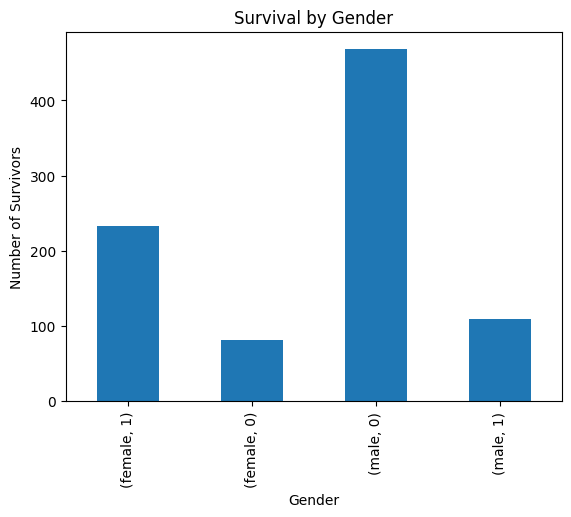

In [35]:
survival_gender = df.groupby('Sex')['Survived'].value_counts()
survival_gender.plot(kind='bar')
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Survivors")
plt.show()

<Axes: xlabel='Survived', ylabel='count'>

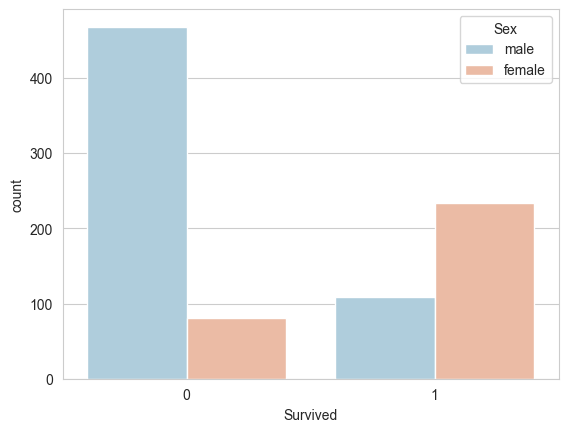

In [12]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Sex',data=df,palette='RdBu_r')

In [36]:
survival_gender

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

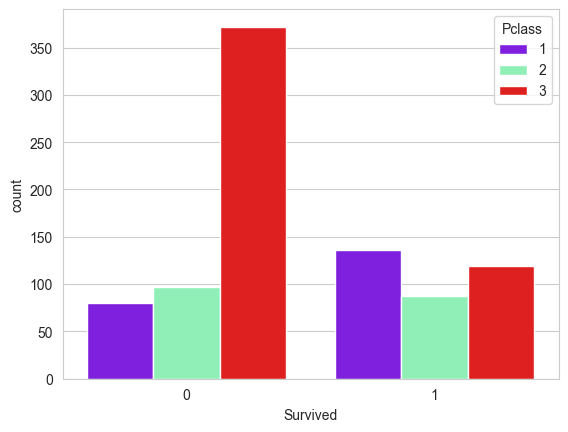

In [13]:
sns.set_style('whitegrid')
sns.countplot(x='Survived',hue='Pclass',data=df,palette='rainbow')

In [14]:
dfg=df.groupby(['Sex','Pclass'])['Survived'].value_counts()

In [15]:
dfg

Sex     Pclass  Survived
female  1       1            91
                0             3
        2       1            70
                0             6
        3       1            72
                0            72
male    1       0            77
                1            45
        2       0            91
                1            17
        3       0           300
                1            47
Name: count, dtype: int64

#### Findings
female passengers had a higher survival rate when we compared with male passengers

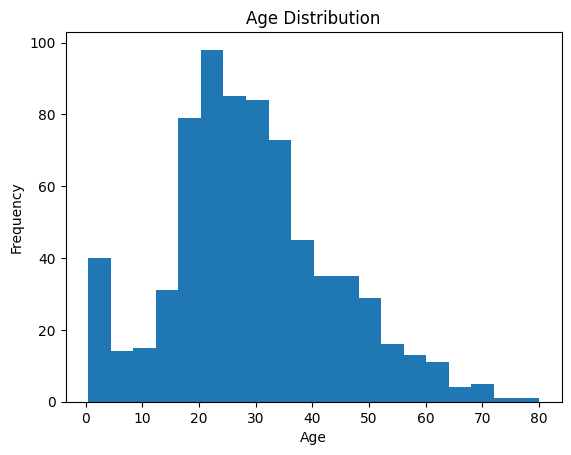

In [43]:
plt.hist(df['Age'],bins=20)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

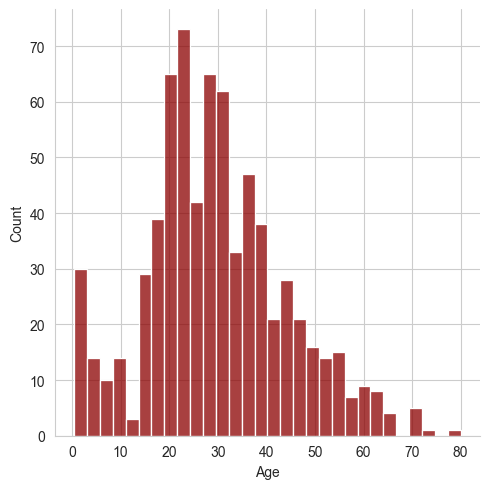

In [16]:
sns.displot(df['Age'].dropna(),kde=False,color='darkred',bins=30)

<Axes: >

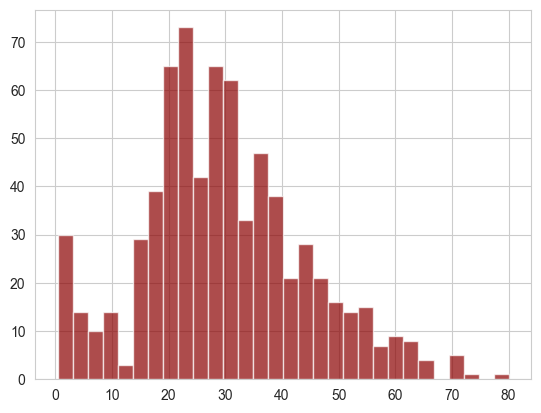

In [17]:
df['Age'].hist(bins=30,color='darkred',alpha=0.7)

In [58]:
df['Age'].value_counts()

Age
24.00    166
37.00     36
29.00     31
22.00     27
18.00     26
        ... 
24.50      1
0.67       1
0.42       1
34.50      1
74.00      1
Name: count, Length: 88, dtype: int64

In [59]:
age_bins=pd.cut(df['Age'],bins=20)
age_count=age_bins.value_counts().sort_index()
print(age_count)

Age
(0.34, 4.399]        40
(4.399, 8.378]       14
(8.378, 12.357]      15
(12.357, 16.336]     31
(16.336, 20.315]     79
(20.315, 24.294]    234
(24.294, 28.273]     85
(28.273, 32.252]     95
(32.252, 36.231]     73
(36.231, 40.21]      75
(40.21, 44.189]      35
(44.189, 48.168]     35
(48.168, 52.147]     29
(52.147, 56.126]     16
(56.126, 60.105]     13
(60.105, 64.084]     11
(64.084, 68.063]      4
(68.063, 72.042]      5
(72.042, 76.021]      1
(76.021, 80.0]        1
Name: count, dtype: int64


majority passengers between 20 and 40 .it indicating that most of the passengerse were adult

<Axes: xlabel='SibSp', ylabel='count'>

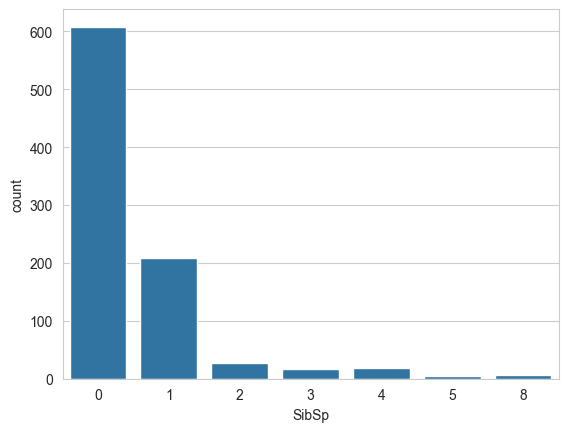

In [18]:
sns.countplot(x='SibSp',data=df)

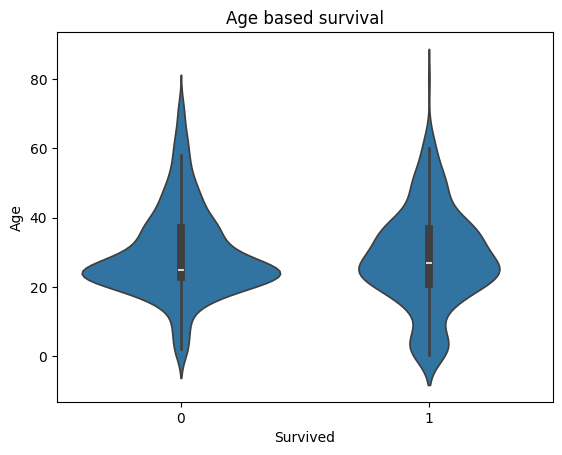

In [51]:
sns.violinplot(x='Survived',y='Age',data=df)
plt.title("Age based survival")
plt.show()

age is not only the factor of survival
here we can see elder people had less chance to survival and children given more priority than elders

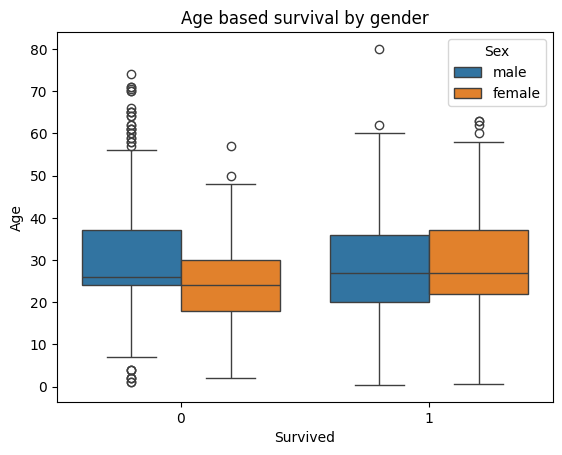

In [53]:
sns.boxplot(x='Survived',y='Age',hue='Sex',data=df)
plt.title("Age based survival by gender")
plt.show()

women had high survival irrespect of age as well as children
adult men were lowest survival rate


In [20]:
df['Pclass'].value_counts().sort_index()

Pclass
1    216
2    184
3    491
Name: count, dtype: int64

In [21]:
pd.crosstab(df['Pclass'],df['Sex'])

Sex,female,male
Pclass,,
1,94,122
2,76,108
3,144,347


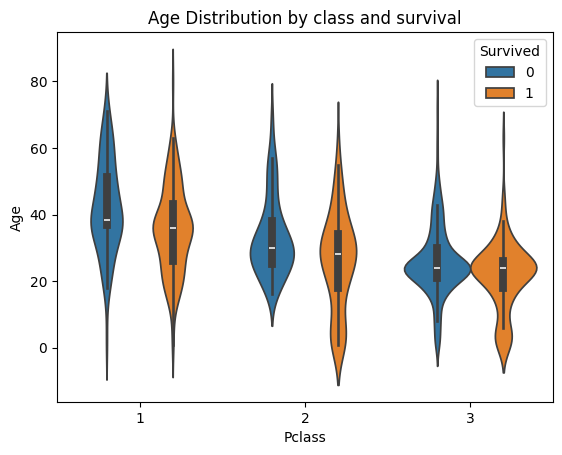

In [54]:
sns.violinplot(x='Pclass',y='Age',hue='Survived',data=df)
plt.title("Age Distribution by class and survival")
plt.show()

###### in first class passengers consist more senior citizens,in contrast third class passengers include more adult and young people this shows that third class consist more families
###### in first class the range of survived is more wider than non survivors it shows higher number of survivors in contrast in third class shows wider distribution for nonsurvivors it says that most of them didnt survived

In [14]:
survived_df=df[df['Survived']==1]

In [16]:
gender_class_survival=pd.crosstab(survived_df['Pclass'],survived_df['Sex'])
print(gender_class_survival)

Sex     female  male
Pclass              
1           91    45
2           70    17
3           72    47


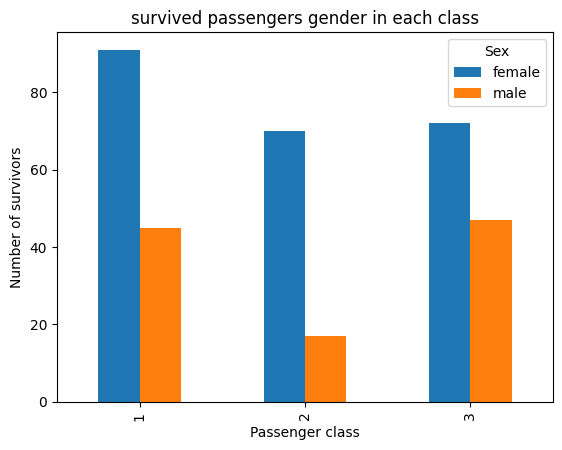

In [18]:
gender_class_survival.plot(kind='bar')
plt.title("survived passengers gender in each class")
plt.xlabel("Passenger class")
plt.ylabel("Number of survivors")
plt.show()

In [44]:
survived_df=df[df['Survived']==0]
gender_class_survival=pd.crosstab(survived_df['Pclass'],survived_df['Sex'])
print(gender_class_survival)


Sex     female  male
Pclass              
1            3    77
2            6    91
3           72   300


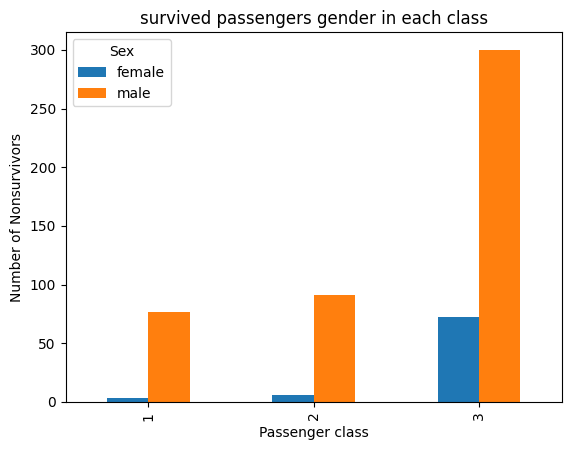

In [46]:
gender_class_survival.plot(kind='bar')
plt.title("survived passengers gender in each class")
plt.xlabel("Passenger class")
plt.ylabel("Number of Nonsurvivors")
plt.show()

###### within each passenger class female had a higher survival rate than male 

##### ? does passenger class influences the survival of females?


In [22]:
female_df=df[df['Sex']=="female"]

In [23]:
female_survival_by_class=female_df.groupby('Pclass')['Survived'].mean()
print(female_survival_by_class)

Pclass
1    0.968085
2    0.921053
3    0.500000
Name: Survived, dtype: float64


#### gender has strong influence in survival but class has an influence in it. even among female those higher class has better survival chance
#### it shows that social status and gender affected rescue priority

# feature engineering

In [25]:
df['FamilyStatus']=df.apply(lambda row:'Alone'if (row['SibSp']==0 and row ['Parch']==0) else 'Family',axis=1)

In [26]:
df['FamilyStatus'].value_counts()

FamilyStatus
Alone     537
Family    354
Name: count, dtype: int64

In [27]:
df.groupby('FamilyStatus')['Survived'].mean()

FamilyStatus
Alone     0.303538
Family    0.505650
Name: Survived, dtype: float64

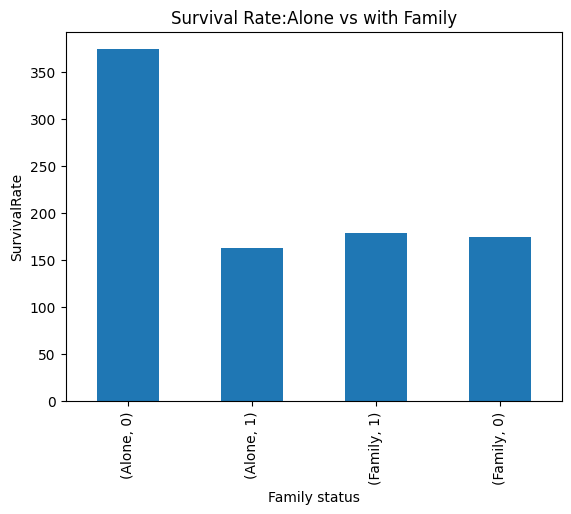

In [47]:
df.groupby('FamilyStatus')['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Rate:Alone vs with Family")
plt.xlabel("Family status")
plt.ylabel("SurvivalRate")
plt.show()

#### family presence shows positive influence in survival outcome whereas isolated passengers were more vulnerable

#### ?Does class change the effect of family?

In [30]:
pd.crosstab(df['Pclass'],df['FamilyStatus'])

FamilyStatus,Alone,Family
Pclass,,
1,109,107
2,104,80
3,324,167


In [31]:
pd.crosstab([df['Pclass'],df['FamilyStatus']],df['Survived'],normalize='index')

Survived                    0         1
Pclass FamilyStatus                    
1      Alone         0.467890  0.532110
       Family        0.271028  0.728972
2      Alone         0.653846  0.346154
       Family        0.362500  0.637500
3      Alone         0.787037  0.212963
       Family        0.700599  0.299401

In [48]:
df.groupby(['Pclass','FamilyStatus'])['Survived'].value_counts()

Pclass  FamilyStatus  Survived
1       Alone         1            58
                      0            51
        Family        1            78
                      0            29
2       Alone         0            68
                      1            36
        Family        1            51
                      0            29
3       Alone         0           255
                      1            69
        Family        0           117
                      1            50
Name: count, dtype: int64

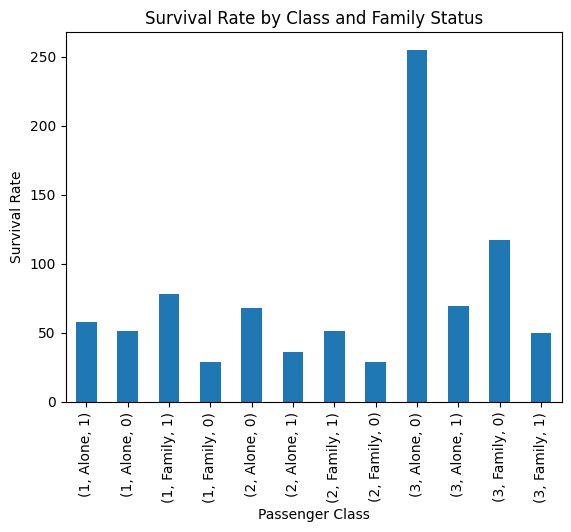

In [52]:
df.groupby(['Pclass','FamilyStatus'])['Survived'].value_counts().plot(kind='bar')
plt.title("Survival Rate by Class and Family Status")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.show()

#### Survival influenced by multiple factors,while family presence improves survival chances ,passenger class plays a dominant role.
#### Third class passengers face lower survival possibilities regardless of family .it shows the impact socio-economic conditions

#### CORE ANALYSIS

#### Gender based:females had higher survival
#### Age based : children had more priority
#### Passenger class based: higher class had higher survival possibility
#### Family based: travelling with family increased survival chance

# Machine Learning

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# (1)Logistic Regression 

### Converting Categorical Features
##### We'll need to convert categorical features to dummy variables using pandas! Otherwise our machine learning algorithm won't be able to directly take in those features as inputs.

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Embarked  891 non-null    str    
dtypes: float64(1), int64(4), str(2)
memory usage: 53.8 KB


In [28]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S
...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,S
887,1,1,female,19.0,0,0,S
888,0,3,female,24.0,1,2,S
889,1,1,male,26.0,0,0,C


In [30]:
sex = pd.get_dummies(df['Sex'],drop_first=True)
embark = pd.get_dummies(df['Embarked'],drop_first=True)

In [31]:
df.drop(['Sex','Embarked'],axis=1,inplace=True)

In [32]:
df=pd.concat([df,sex,embark],axis=1)

In [33]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,male,Q,S
0,0,3,22.0,1,0,True,False,True
1,1,1,38.0,1,0,False,False,False
2,1,3,26.0,0,0,False,False,True
3,1,1,35.0,1,0,False,False,True
4,0,3,35.0,0,0,True,False,True


##### data ready for model

### Building a logistic regression model

###### Train Test Split :
###### (Let's start by splitting our data into a training set and test set)

In [92]:
from sklearn.model_selection import train_test_split

In [93]:
X_train, X_test, y_train, y_test = train_test_split(df.drop('Survived',axis=1),df['Survived'], test_size=0.30,random_state=101)

##### Training and predicting :

In [94]:
from sklearn.linear_model import LogisticRegression

In [95]:
logmodel = LogisticRegression()
logmodel.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [96]:
pred_log = logmodel.predict(X_test)

In [97]:
pred_log

array([0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1,
       0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 1])

#### Evaluation

In [98]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[132  22]
 [ 34  80]]
              precision    recall  f1-score   support

           0       0.80      0.86      0.82       154
           1       0.78      0.70      0.74       114

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



In [ ]:
#eg

In [44]:
logmodel.predict([[3,22.0,1,0,1,0,1]])

C:\Users\prade\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


array([0])

# (2) Decision Tree Classifier

#### Train Test Split :

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
X=df.drop('Survived',axis=1)
y=df['Survived']

In [101]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30,random_state=101)

#### Training and prediction :

In [102]:
from sklearn.tree import DecisionTreeClassifier

In [103]:
dtree=DecisionTreeClassifier()

In [104]:
dtree.fit(X_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [105]:
pred_dt = dtree.predict(X_test)

In [106]:
pred_dt

array([0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       1, 1, 0, 1])

#### Evaluation

In [107]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[132  22]
 [ 34  80]]
              precision    recall  f1-score   support

           0       0.80      0.86      0.82       154
           1       0.78      0.70      0.74       114

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.78       268
weighted avg       0.79      0.79      0.79       268



##### check overfitting

In [66]:
print("Train Accuracy:", dtree.score(X_train, y_train))
print("Test Accuracy:", dtree.score(X_test, y_test))

Train Accuracy: 0.9486356340288925
Test Accuracy: 0.7835820895522388


###### if it over fitt do this:
dtree = DecisionTreeClassifier(
    max_depth=3,
    min_samples_leaf=5,
    random_state=101
)

dtree.fit(X_train, y_train)
predictions_dt = dtree.predict(X_test)

##### feature importnace

In [67]:
import pandas as pd

feature_importance = pd.Series(dtree.feature_importances_, index=X_train.columns)
print(feature_importance.sort_values(ascending=False))

male      0.362281
Age       0.323781
Pclass    0.119374
SibSp     0.087462
Parch     0.062922
S         0.033580
Q         0.010599
dtype: float64


###### Which features influence survival most

# (3)RandomForest Classification


In [110]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100)
rfc.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [111]:
pred_rf= rfc.predict(X_test)

In [112]:
print(pred_rf)

[0 1 0 0 0 0 0 0 1 1 0 1 1 0 0 1 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0
 0 0 1 0 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1 1 1 1 1 0 0 1 0 1 0 0 1 0 1 1 1 0 0
 0 1 0 1 1 1 0 0 1 0 0 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1
 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0 1 0 1 1 1
 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1
 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0 1
 0 1 1 0 0 1 1 0 1]


In [113]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_test, predictions))
print(classification_report(y_test, predictions))

[[132  22]
 [ 33  81]]
              precision    recall  f1-score   support

           0       0.80      0.86      0.83       154
           1       0.79      0.71      0.75       114

    accuracy                           0.79       268
   macro avg       0.79      0.78      0.79       268
weighted avg       0.79      0.79      0.79       268



##### feature impoprtance

In [70]:
import pandas as pd

importance = pd.Series(rfc.feature_importances_, index=X_train.columns)
print(importance.sort_values(ascending=False))

Age       0.380790
male      0.313200
Pclass    0.121968
SibSp     0.077691
Parch     0.061633
S         0.031346
Q         0.013372
dtype: float64


## TO IMPROVE RANDOM FOREST

In [ ]:
rfc = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    random_state=101
)

rfc.fit(X_train, y_train)
predictions = rfc.predict(X_test)

# (4) K-Nearest Neighbors

In [71]:
from sklearn.neighbors import KNeighborsClassifier

##### Scaling of features is important in knn

In [72]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [73]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [76]:
pred_knn = knn.predict(X_test_scaled)
print(pred_knn)

[0 1 1 0 0 0 0 0 1 1 0 1 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0
 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 1 1 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1 1 1 1 1 0 0 1 0 1 0 0 1 0 1 1 1 0 0
 1 0 0 1 0 1 0 0 1 1 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 0
 0 0 1 1 0 0 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 1 1
 0 0 1 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0 1 0 1 1 1
 0 0 0 0 0 0 0 0 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1
 0 1 1 1 0 1 1 0 1]


In [75]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, pred_knn))
print(classification_report(y_test, pred_knn))

[[131  23]
 [ 36  78]]
              precision    recall  f1-score   support

           0       0.78      0.85      0.82       154
           1       0.77      0.68      0.73       114

    accuracy                           0.78       268
   macro avg       0.78      0.77      0.77       268
weighted avg       0.78      0.78      0.78       268



# (5) Support Vector Machine

In [77]:
from sklearn.svm import SVC

In [78]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [79]:
svm_model = SVC()
svm_model.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [81]:
pred_svm = svm_model.predict(X_test_scaled)
print(pred_svm)

[0 1 0 1 0 0 0 0 1 1 0 0 1 0 0 0 0 0 0 1 0 0 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0
 0 0 0 0 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 0 1 1 0 0 0 0 0 1 0 1 0 0 0 0 0
 0 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 0 1 1 1 0 1 0 0 0 1 0 1 0 0 0 0 1 1 1 0 0
 0 0 0 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0
 0 0 1 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 0 1 0 0 1 0 0 1 0 0 1 0 0 0 0 0 1 1 1
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 1 1 1
 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 0 1 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1
 0 0 1 0 0 1 1 0 1]


In [82]:
from sklearn.metrics import confusion_matrix, classification_report
print(confusion_matrix(y_test, pred_svm))
print(classification_report(y_test, pred_svm))

[[146   8]
 [ 42  72]]
              precision    recall  f1-score   support

           0       0.78      0.95      0.85       154
           1       0.90      0.63      0.74       114

    accuracy                           0.81       268
   macro avg       0.84      0.79      0.80       268
weighted avg       0.83      0.81      0.81       268



# (6) Naive Bayes

In [83]:
from sklearn.naive_bayes import GaussianNB

In [84]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [85]:
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [87]:
pred_nb = nb.predict(X_test_scaled)
print(pred_nb)

[0 1 0 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 0 1 0 0 1 1 0 0 0 0 0 0 1 1 1 0 0 1 0
 0 0 0 1 1 1 0 0 0 0 0 0 0 1 1 1 1 1 0 0 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0
 1 1 0 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 1 1 1 1 0 0 0 0 1 0 0 1 1 1 1 1 0 0
 0 0 0 1 1 1 0 0 1 0 0 1 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 1 0 1 1
 0 0 1 1 1 0 0 1 1 0 1 1 0 0 1 0 1 1 0 1 0 0 1 0 1 1 0 0 1 0 0 0 0 0 1 1 1
 0 0 1 0 0 0 0 0 1 1 0 0 1 0 0 0 1 0 1 0 1 0 1 1 0 1 0 0 0 1 0 0 1 0 1 1 0
 0 0 0 1 0 0 0 0 0 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 0 0 1 0 0 1 0 0 0 0 0 0 1
 0 0 1 0 0 1 0 0 1]


In [88]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
print(confusion_matrix(y_test, pred_nb))
print(classification_report(y_test, pred_nb))
print("Accuracy:", accuracy_score(y_test, pred_nb))

[[127  27]
 [ 34  80]]
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       154
           1       0.75      0.70      0.72       114

    accuracy                           0.77       268
   macro avg       0.77      0.76      0.77       268
weighted avg       0.77      0.77      0.77       268

Accuracy: 0.7723880597014925


### compare which model is best to predict

In [90]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def evaluate(name, y_test, preds):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1 Score": f1_score(y_test, preds)}

In [114]:
results = []

results.append(evaluate("Logistic Regression", y_test, pred_log))
results.append(evaluate("Decision Tree", y_test,pred_dt))
results.append(evaluate("Random Forest", y_test, pred_rf))
results.append(evaluate("KNN", y_test, pred_knn))
results.append(evaluate("SVM", y_test, pred_svm))
results.append(evaluate("Naive Bayes", y_test, pred_nb))

In [115]:
import pandas as pd
results_df = pd.DataFrame(results)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.791045   0.802083  0.675439  0.733333
1        Decision Tree  0.779851   0.795699  0.649123  0.714976
2        Random Forest  0.783582   0.780000  0.684211  0.728972
3                  KNN  0.779851   0.772277  0.684211  0.725581
4                  SVM  0.813433   0.900000  0.631579  0.742268
5          Naive Bayes  0.772388   0.747664  0.701754  0.723982


In [ ]:
#sort

In [116]:
print(results_df.sort_values(by="F1 Score", ascending=False))

                 Model  Accuracy  Precision    Recall  F1 Score
4                  SVM  0.813433   0.900000  0.631579  0.742268
0  Logistic Regression  0.791045   0.802083  0.675439  0.733333
2        Random Forest  0.783582   0.780000  0.684211  0.728972
3                  KNN  0.779851   0.772277  0.684211  0.725581
5          Naive Bayes  0.772388   0.747664  0.701754  0.723982
1        Decision Tree  0.779851   0.795699  0.649123  0.714976


# CONCLUSION
Among all models, Support Vector Machine achieved the highest overall performance with an F1-score of 0.742 and accuracy of 81.3%. However, Logistic Regression demonstrated better recall for the positive class, making it more suitable when identifying survivors is critical. The results indicate that while SVM provides the best balanced performance, model selection should depend on the specific objective of minimizing false negatives or maximizing prediction confidence.

# ROC

In [119]:
svm_model = SVC(probability=True)
svm_model.fit(X_train_scaled, y_train)
svm_probs = svm_model.predict_proba(X_test_scaled)[:,1]
log_probs = logmodel.predict_proba(X_test)[:,1]
rf_probs  = rfc.predict_proba(X_test)[:,1]
nb_probs  = nb.predict_proba(X_test_scaled)[:,1]

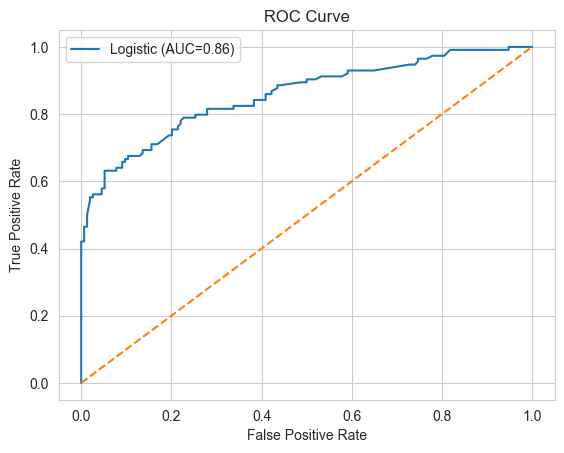

In [121]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt
fpr, tpr, _ = roc_curve(y_test, log_probs)
auc = roc_auc_score(y_test, log_probs)
plt.plot(fpr, tpr, label=f'Logistic (AUC={auc:.2f})')
plt.plot([0,1],[0,1],'--')  # random line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

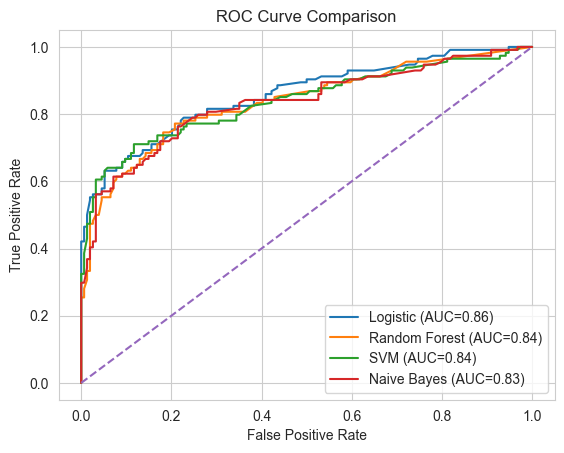

In [122]:
plt.figure()

for name, probs in [
    ("Logistic", log_probs),
    ("Random Forest", rf_probs),
    ("SVM", svm_probs),
    ("Naive Bayes", nb_probs)
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')

plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

In [ ]:
#Curve closer to top-left → better
#Higher AUC → better model

# AUC

In [123]:
from sklearn.metrics import roc_auc_score
print("Logistic AUC:", roc_auc_score(y_test, log_probs))
print("Random Forest AUC:", roc_auc_score(y_test, rf_probs))
print("SVM AUC:", roc_auc_score(y_test, svm_probs))
print("Naive Bayes AUC:", roc_auc_score(y_test, nb_probs))

Logistic AUC: 0.856345408976988
Random Forest AUC: 0.8356971975393028
SVM AUC: 0.8384882661198452
Naive Bayes AUC: 0.8328206880838459


# FINAL CONCLUSION
In this project, multiple classification models were implemented to predict passenger survival on the Titanic dataset, including Logistic Regression, Decision Tree, Random Forest, KNN, SVM, and Naive Bayes. Model performance was evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Based on the evaluation:

Support Vector Machine achieved the highest F1-score (0.742) and accuracy (81.34%), indicating the best overall balance between precision and recall.
However, Logistic Regression achieved the highest ROC-AUC score (0.856), demonstrating the strongest ability to distinguish between survivors and non-survivors across all classification thresholds.

Although SVM performed best in terms of classification metrics, Logistic Regression showed more stable and consistent performance, particularly with better recall and the highest AUC. This indicates that Logistic Regression generalizes better and is more reliable for ranking predictions.

Other models such as Random Forest, KNN, and Naive Bayes performed reasonably well but did not surpass the top two models. The Decision Tree model showed comparatively lower performance, likely due to overfitting.